# Solving Spelling Bee 100x faster

[Spelling Bee](https://www.nytimes.com/puzzles/spelling-bee) is a game by New York Time where you have to create as many words as possible given 7 distinct letters, including one (the central one) that you must use.

![Spelling Bee](https://static01.nyt.com/images/2022/08/11/14morning-bee-april-6/oakImage-1660249828142-articleLarge.png?quality=75&auto=webp&disable=upscale)

Let's solve it programatically:
* The naive approach is simple: iterate through all the English words, check if they follow the game rules (use only the accepted letters, use the central letter, use more than 3 characters), and save the words that do. The runtime complexity is O(#words in English * avg length of word)
* We can improve runtime by building a [Trie](https://en.wikipedia.org/wiki/Trie) of all the words in English, and exploring it in depth first first with backtracking. This scales in O(#valid words * avg length of word), which gives a nice 100x speed-up!

# 1. Import vocab

We use TWL06 as our dictionary, which is the official Scrabble dictionary.

In [1]:
import urllib.request

url = "https://raw.githubusercontent.com/d48/scrabble-with-friends-python/master/TWL06.txt"


with urllib.request.urlopen(url) as response:
    # Read the text, decode it, split by lines, and clean up formatting
    twl06_words = [line.decode('utf-8').strip().lower() for line in response if line.strip()]

# 2. Naive algo

In [2]:
from collections.abc import Iterable


def solve_word_search(must_use_letter: str, allowed_letters: Iterable[str], vocab: Iterable[str]) -> list[str]:
  assert(must_use_letter in allowed_letters and len(allowed_letters) == 7 and len(must_use_letter) == 1)
  ans = []
  for word in vocab:
    if len(word) > 3 and must_use_letter in word and all(c in allowed_letters for c in word):
      ans.append(word)
  return ans

In [3]:
solve_word_search(must_use_letter="a", allowed_letters=["a", "c", "t", "s", "w", "o", "p"], vocab=["cats", "dogs"])

['cats']

# 3. Trie

In the trie approach, we first need to build the trie (we do this only one time, after that we only search the trie).

In [4]:
# trie node
class Node:
  """
  The value of a node is a letter. We have two special values: "" (empty char) for the root, and "#" to mark the end of a word.
  """
  def __init__(self, val, child=None):
    self.val = val
    self.child = child if child is not None else {}

  def __repr__(self) -> str:
    return f"Node({self.val})"


def add_word_to_subtree(root, word):
  curr_node = root
  for c in word:
    if c in curr_node.child:
      curr_node = curr_node.child[c]
    else:
      new_node = Node(val=c, child={})
      curr_node.child[c] = new_node
      curr_node = new_node
  curr_node.child["#"] = Node("#", [])
  return root


def build_trie(vocab):
  root = Node("", None)
  for word in vocab:
    add_word_to_subtree(root, word)
  return root


root = build_trie(vocab=["cats", "dogs"])

In [5]:
print("Displaying how 'cats' is saved")
print(f"{root} with child {root.child}")
print(f"{root.child['c']} with child {root.child['c'].child}")
print(f"{root.child['c'].child['a']} with child {root.child['c'].child['a'].child}")
print(f"{root.child['c'].child['a'].child['t']} with child {root.child['c'].child['a'].child['t'].child}")
print(f"{root.child['c'].child['a'].child['t'].child['s']} with child {root.child['c'].child['a'].child['t'].child['s'].child}")

Displaying how 'cats' is saved
Node() with child {'c': Node(c), 'd': Node(d)}
Node(c) with child {'a': Node(a)}
Node(a) with child {'t': Node(t)}
Node(t) with child {'s': Node(s)}
Node(s) with child {'#': Node(#)}


After, that we explore the trie with depth first search and backtracking.

In [6]:
def solve_word_search_with_dfs(must_use_letter, allowed_letters, root):
  curr_node = root
  ans = []
  path_so_far = []

  def dfs_subtree(node):
    if node.val == "#":
      if must_use_letter in path_so_far and len(path_so_far) > 4: # 4 because the path starts with ""
        word = "".join(path_so_far)
        ans.append(word)
      return

    path_so_far.append(node.val)
    for children in node.child.values():
      if children.val in allowed_letters or children.val=="#":
        dfs_subtree(children)
    path_so_far.pop(-1)
    return

  dfs_subtree(root)
  return ans

solve_word_search_with_dfs(must_use_letter="a", allowed_letters=["a", "c", "t", "s", "w", "o", "p"], root=root)

['cats']

# 4. Correctness and speed check

This helper function generates random Spelling Bee configurations

In [7]:
import random
import string

def generate_random_game():
  all_letters = string.ascii_lowercase
  sampled_letters_list = random.sample(all_letters, 7)
  return set(sampled_letters_list), sampled_letters_list[0]

allowed_letters, must_use_letter = generate_random_game()
print(f"Generated letters: {allowed_letters}")
print(f"Must-use letter: {must_use_letter}")

Generated letters: {'b', 'y', 'k', 'r', 'i', 'd', 'l'}
Must-use letter: b


Let's time 100 random games, and make sure that both algorithms give the same result.

In [8]:
# for the trie approach, we first need to build the trie
root = build_trie(vocab=twl06_words)

In [9]:
import time

times_word_search = []
times_word_search_with_dfs = []

for _ in range(100):
  allowed_letters, must_use_letter = generate_random_game()

  start = time.perf_counter()
  ans1 = solve_word_search(must_use_letter, allowed_letters, vocab=twl06_words)
  times_word_search.append(time.perf_counter() - start)

  start = time.perf_counter()
  ans2 = solve_word_search_with_dfs(must_use_letter, allowed_letters, root)
  times_word_search_with_dfs.append(time.perf_counter() - start)

  assert(set(ans1) == set(ans2))

In [10]:
import numpy as np

print(f"Average runtime for naive: {round(np.mean(times_word_search) * 1_000, 1)} ms")
print(f"Average runtime for trie: {round(np.mean(times_word_search_with_dfs) * 1_000, 1)} ms")

Average runtime for naive: 42.9 ms
Average runtime for trie: 0.7 ms


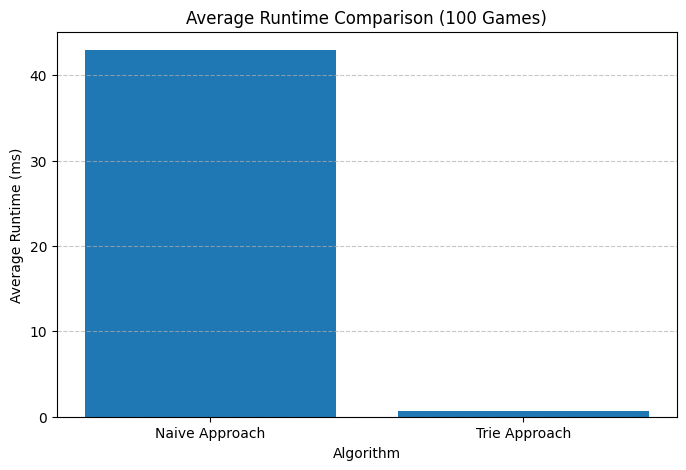

In [11]:
from matplotlib import pyplot as plt
plt.figure(figsize=(8, 5))
plt.bar(
    [0, 1],
    [np.mean(times_word_search) * 1_000, np.mean(times_word_search_with_dfs) * 1_000],
    tick_label=["Naive Approach", "Trie Approach"]
)
plt.title("Average Runtime Comparison (100 Games)")
plt.xlabel("Algorithm")
plt.ylabel("Average Runtime (ms)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()